In [10]:
import pandas as pd
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

In [3]:
# CARGA DE BASE DE DATOS
df = pd.read_csv("Cali_historico_saber11_13022024_20260307.zip", sep=",")


In [4]:
# ESTADISTICAS POR PUNTAJE
print("=== Estadísticas descriptivas de Puntajes por Área de Estudio 2010 - 2022 ===")
punt_cols = df.filter(like="PUNT_")
display(punt_cols.describe())

=== Estadísticas descriptivas de Puntajes por Área de Estudio 2010 - 2022 ===


,PUNT_INGLES,PUNT_MATEMATICAS,PUNT_SOCIALES_CIUDADANAS,PUNT_C_NATURALES,PUNT_LECTURA_CRITICA,PUNT_GLOBAL
count,346977.000000,347028.000000,196295.000000,196295.000000,196295.000000,196295.000000
mean,50.547680,50.138252,50.853705,51.686243,54.178486,261.180687
std,13.351645,12.073257,11.937698,10.998659,10.317050,51.513134
min,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,42.000000,42.000000,42.000000,44.000000,47.000000,223.000000
50%,48.000000,49.430000,51.000000,51.000000,54.000000,258.000000
75%,57.000000,58.000000,59.000000,59.000000,61.000000,296.000000
max,116.950000,127.000000,100.000000,100.000000,100.000000,495.000000


In [27]:
#Años

print("=== Años disponibles en el dataset ===")

df["AÑO"] = df["PERIODO"].astype(str).str[:4]
lista_años = sorted(df["AÑO"].unique())
print(lista_años)

#Control de NAs

print("=== Control de NaNs ===")

nan_counts = df.isna().sum()
nan_percent = (nan_counts / len(df)) * 100
nan_info = pd.DataFrame({
    "NaN_count": nan_counts,
    "NaN_percent": nan_percent
})
nan_info = nan_info[nan_info["NaN_count"] > 0].sort_values(by="NaN_count", ascending=False)

print(nan_info)


=== Años disponibles en el dataset ===
['2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022']
=== Control de NaNs ===
                               NaN_count  NaN_percent
PUNT_GLOBAL                       150733    43.435400
PUNT_LECTURA_CRITICA              150733    43.435400
PUNT_C_NATURALES                  150733    43.435400
PUNT_SOCIALES_CIUDADANAS          150733    43.435400
COLE_BILINGUE                      35409    10.203499
FAMI_EDUCACIONPADRE                13665     3.937723
FAMI_EDUCACIONMADRE                13646     3.932248
FAMI_ESTRATOVIVIENDA               12081     3.481275
FAMI_TIENEINTERNET                 11765     3.390216
FAMI_TIENECOMPUTADOR               10771     3.103784
FAMI_TIENEAUTOMOVIL                 9048     2.607282
FAMI_PERSONASHOGAR                  8818     2.541005
FAMI_CUARTOSHOGAR                   8738     2.517952
FAMI_TIENELAVADORA                  8692     2.504697
COLE_CARACTER         

In [5]:
# ESTADISTICAS POR TIPO DE AREA DONDE SE ENCUENTRA LA INSTITUCION EDUCATIVA
df["PERIODO"] = pd.to_numeric(df["PERIODO"], errors="coerce")

fig = px.box(
    df,
    x="PERIODO",                
    y="PUNT_GLOBAL",            
    color="COLE_AREA_UBICACION",
    title="Distribución de PUNT_GLOBAL por año y área"
)

fig.update_layout(
    xaxis_title="Año",
    yaxis_title="Puntaje Global",
    legend_title="Área de ubicación"
)

fig.show()


In [9]:


punt_cols = [
    "PUNT_INGLES",
    "PUNT_MATEMATICAS",
    "PUNT_SOCIALES_CIUDADANAS",
    "PUNT_C_NATURALES",
    "PUNT_LECTURA_CRITICA"
]

df_long = df.melt(
    id_vars=["COLE_CARACTER"], 
    value_vars=punt_cols,
    var_name="Asignatura",
    value_name="Puntaje"
)

def plot_caracter(caracter):
    df_filtrado = df_long[df_long["COLE_CARACTER"] == caracter]
    plt.figure(figsize=(10,6))
    sns.barplot(
        data=df_filtrado,
        x="Asignatura",
        y="Puntaje",
        ci=None
    )
    plt.title(f"Distribución de puntajes por asignatura - {caracter}")
    plt.xlabel("Asignatura")
    plt.ylabel("Puntaje promedio")
    plt.xticks(rotation=30)
    plt.show()

dropdown = widgets.Dropdown(
    options=df["COLE_CARACTER"].unique(),
    description="Carácter:"
)

widgets.interactive(plot_caracter, caracter=dropdown)


interactive(children=(Dropdown(description='Carácter:', options=('TÉCNICO/ACADÉMICO', 'ACADÉMICO', 'TÉCNICO', …

In [12]:

# Variables de interés
fami_cols = [
    "FAMI_TIENEAUTOMOVIL",
    "FAMI_TIENECOMPUTADOR",
    "FAMI_TIENEINTERNET",
    "FAMI_TIENELAVADORA"
]

def plot_estrato(estrato):
    df_filtrado = df[df["FAMI_ESTRATOVIVIENDA"] == estrato]
    
    df_long = df_filtrado.melt(
        id_vars=["FAMI_ESTRATOVIVIENDA"],
        value_vars=fami_cols,
        var_name="Bien",
        value_name="Respuesta"
    )
    
    conteo = df_long.groupby(["Bien", "Respuesta"]).size().reset_index(name="Conteo")
    
    plt.figure(figsize=(10,6))
    sns.barplot(
        data=conteo,
        x="Bien",
        y="Conteo",
        hue="Respuesta",
        ci=None
    )
    plt.title(f"Conteo de bienes familiares por estrato {estrato}")
    plt.xlabel("Bien")
    plt.ylabel("Número de respuestas")
    plt.xticks(rotation=30)
    plt.legend(title="Respuesta")
    plt.show()

dropdown = widgets.Dropdown(
    options=df["FAMI_ESTRATOVIVIENDA"].unique(),
    description="Estrato:"
)

widgets.interactive(plot_estrato, estrato=dropdown)


interactive(children=(Dropdown(description='Estrato:', options=('Estrato 5', 'Estrato 4', 'Estrato 3', 'Estrat…

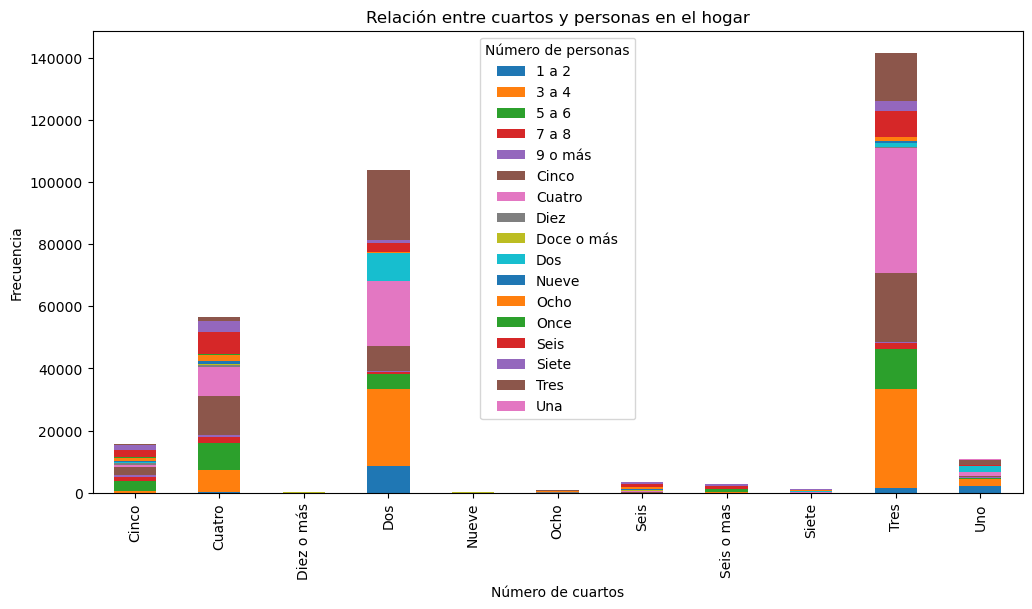

In [14]:
import pandas as pd

# Tabla cruzada
tabla = pd.crosstab(df["FAMI_CUARTOSHOGAR"], df["FAMI_PERSONASHOGAR"])

# Gráfico de barras apiladas
tabla.plot(kind="bar", stacked=True, figsize=(12,6))
plt.title("Relación entre cuartos y personas en el hogar")
plt.xlabel("Número de cuartos")
plt.ylabel("Frecuencia")
plt.legend(title="Número de personas")
plt.show()



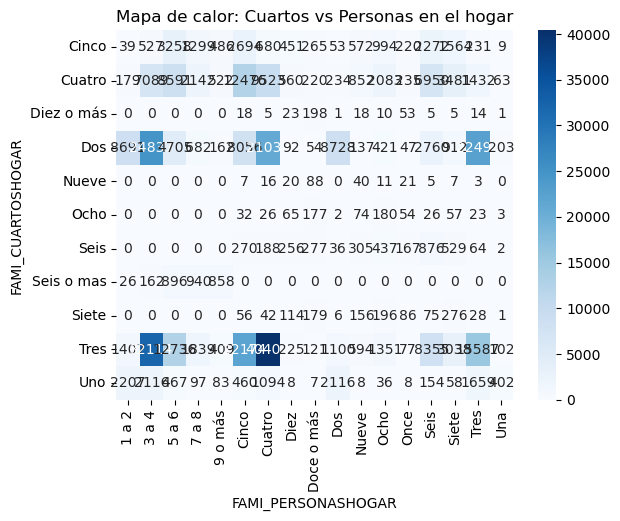